# Step 2 — POS Tagging
**Project:** Same Reality, Different Words  
**Author:** Paula Andrea Jaramillo  
**Program:** MSc Data Science for Society and Business — Constructor University Bremen  

## Objective
Apply Part-of-Speech (POS) tagging to the original texts using spaCy (`en_core_web_sm`).  
For each document, we compute the distribution of POS categories and analyze whether different registers (Institutional, Popular Media, Critical Media) rely on systematically different grammatical structures.

**Research connection:**  
- Institutional texts are expected to use more **nouns** and **adjectives** (nominalization, technical precision)  
- Popular media texts are expected to use more **verbs** and **adverbs** (narrative, action-driven)  
- Critical media texts are expected to show higher **verb** and **noun** density (named actors + systemic consequences)

**Input:** `corpus_preprocessed.csv` (output of Step 1)  
**Output:** `corpus_pos.csv` (adds POS count columns per document)

## 1. Imports and Setup

In [1]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

print("spaCy version:", spacy.__version__)
print("Model loaded: en_core_web_sm")

spaCy version: 3.8.14
Model loaded: en_core_web_sm


## 2. Load Preprocessed Corpus

In [2]:
# Adjust path as needed
df = pd.read_csv("corpus_preprocessed.csv")

print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(f"Registers: {df['register'].value_counts().to_dict()}")
df.head(3)

Rows: 180 | Columns: 7
Registers: {'institutional': 60, 'popular_media': 60, 'critical_media': 60}


,text,text_clean,label,register,prompt_id,token_count_original,token_count_clean
0,"In Colombia, the share of workers lacking form...",colombia share worker lack formal contract reg...,0,institutional,A001,29,18
1,Social protection coverage among own-account w...,social protection coverage account worker info...,0,institutional,A002,25,18
2,Labor formality indicators for the 13 main met...,labor formality indicator main metropolitan ar...,0,institutional,A003,23,15


## 3. POS Tagging Function

We apply POS tagging to the **original text** (not the cleaned version), since `text_clean` has already removed stopwords and applied lemmatization, which would distort POS distributions.  
We focus on six universal POS tags: `NOUN`, `VERB`, `ADJ`, `ADV`, `PROPN` (proper nouns), `NUM` (numbers).

In [3]:
# POS tags of interest
TARGET_POS = ["NOUN", "VERB", "ADJ", "ADV", "PROPN", "NUM"]

def get_pos_counts(text):
    """
    Given a raw text string, returns a dict with:
    - Absolute count for each target POS tag
    - Total token count (excluding punctuation and spaces)
    - Relative frequency (proportion) for each target POS tag
    """
    doc = nlp(text)
    tokens = [token for token in doc if not token.is_punct and not token.is_space]
    total = len(tokens)
    
    counts = Counter(token.pos_ for token in tokens)
    
    result = {"total_tokens": total}
    for pos in TARGET_POS:
        result[f"count_{pos.lower()}"] = counts.get(pos, 0)
        result[f"ratio_{pos.lower()}"] = round(counts.get(pos, 0) / total, 4) if total > 0 else 0
    
    return result

# Test on a single example
example = df["text"].iloc[0]
print("Example text:", example[:100], "...")
print("POS result:", get_pos_counts(example))

Example text: In Colombia, the share of workers lacking formal contract registration remained at 57.3 percent in t ...
POS result: {'total_tokens': 29, 'count_noun': 10, 'ratio_noun': 0.3448, 'count_verb': 3, 'ratio_verb': 0.1034, 'count_adj': 4, 'ratio_adj': 0.1379, 'count_adv': 1, 'ratio_adv': 0.0345, 'count_propn': 1, 'ratio_propn': 0.0345, 'count_num': 1, 'ratio_num': 0.0345}


## 4. Apply POS Tagging to Full Corpus

In [4]:
# Apply to all texts
print("Applying POS tagging to 180 documents...")
pos_data = df["text"].apply(get_pos_counts)
pos_df = pd.DataFrame(pos_data.tolist())

# Merge with original dataframe
df_pos = pd.concat([df, pos_df], axis=1)

print(f"New shape: {df_pos.shape}")
print(f"New columns added: {pos_df.columns.tolist()}")
df_pos[["register", "total_tokens", "count_noun", "count_verb", "count_adj", "ratio_noun", "ratio_verb"]].head(5)

Applying POS tagging to 180 documents...
New shape: (180, 20)
New columns added: ['total_tokens', 'count_noun', 'ratio_noun', 'count_verb', 'ratio_verb', 'count_adj', 'ratio_adj', 'count_adv', 'ratio_adv', 'count_propn', 'ratio_propn', 'count_num', 'ratio_num']


,register,total_tokens,count_noun,count_verb,count_adj,ratio_noun,ratio_verb
0,institutional,29,10,3,4,0.3448,0.1034
1,institutional,27,10,3,5,0.3704,0.1111
2,institutional,23,12,1,3,0.5217,0.0435
3,institutional,24,8,1,6,0.3333,0.0417
4,institutional,25,11,3,4,0.4400,0.1200


## 5. POS Distribution by Register

We compute the **mean ratio** of each POS tag per register to compare grammatical profiles.

In [5]:
ratio_cols = [f"ratio_{pos.lower()}" for pos in TARGET_POS]

pos_by_register = df_pos.groupby("register")[ratio_cols].mean().round(4)
pos_by_register.columns = [c.replace("ratio_", "").upper() for c in pos_by_register.columns]

print("Mean POS ratios by register:")
print(pos_by_register.to_string())

Mean POS ratios by register:
                  NOUN    VERB     ADJ     ADV   PROPN     NUM
register                                                      
critical_media  0.2936  0.1034  0.0952  0.0172  0.1039  0.0560
institutional   0.3894  0.1015  0.1590  0.0213  0.0125  0.0237
popular_media   0.2992  0.1424  0.0847  0.0321  0.0316  0.0098


## 6. Visualizations

### 6.1 Grouped Bar Chart — POS Ratios by Register

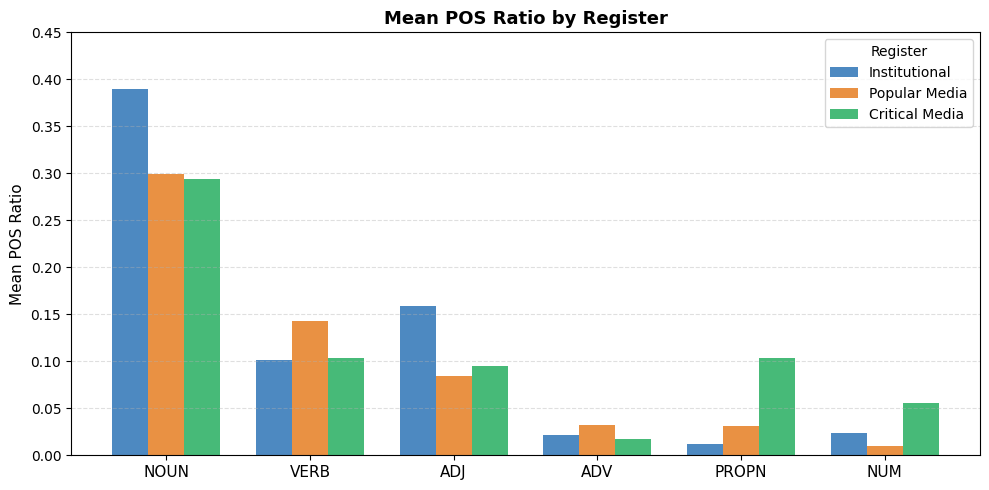

Figure saved: step2_pos_by_register.png


In [6]:
register_order = ["institutional", "popular_media", "critical_media"]
register_labels = ["Institutional", "Popular Media", "Critical Media"]
colors = ["#2E75B6", "#E67E22", "#27AE60"]

pos_plot = pos_by_register.loc[register_order]

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(pos_plot.columns))
width = 0.25

for i, (reg, color) in enumerate(zip(register_order, colors)):
    vals = pos_plot.loc[reg].values
    ax.bar([xi + i * width for xi in x], vals, width=width,
           label=register_labels[i], color=color, alpha=0.85)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(pos_plot.columns, fontsize=11)
ax.set_ylabel("Mean POS Ratio", fontsize=11)
ax.set_title("Mean POS Ratio by Register", fontsize=13, fontweight="bold")
ax.legend(title="Register", fontsize=10)
ax.set_ylim(0, 0.45)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("step2_pos_by_register.png", dpi=150)
plt.show()
print("Figure saved: step2_pos_by_register.png")

### 6.2 Boxplots — Distribution of NOUN and VERB ratios per Register

C:\Users\jaram\AppData\Local\Temp\ipykernel_7156\1809942340.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_reg, labels=register_labels, patch_artist=True,
C:\Users\jaram\AppData\Local\Temp\ipykernel_7156\1809942340.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_reg, labels=register_labels, patch_artist=True,


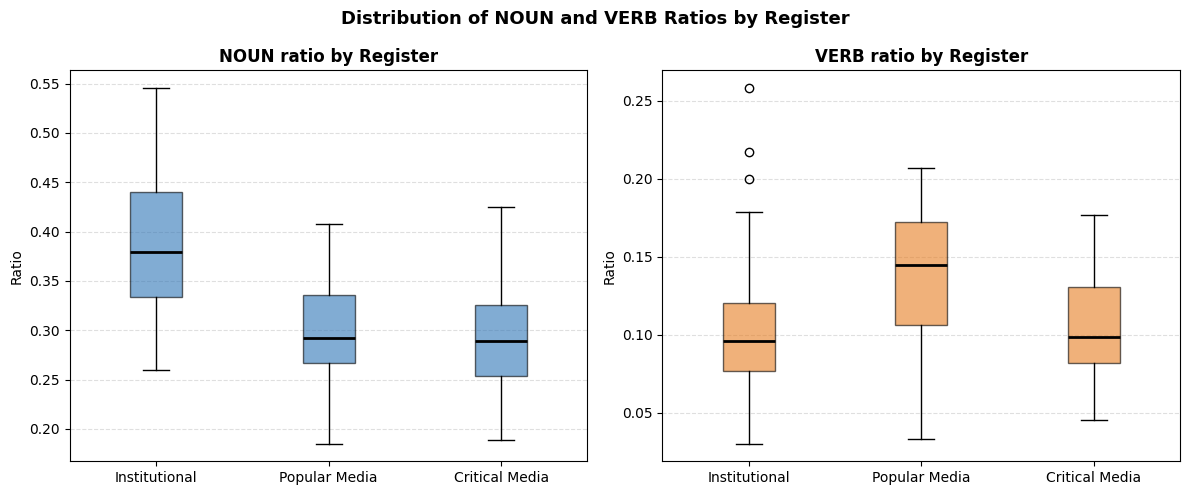

Figure saved: step2_noun_verb_boxplots.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pos_tag, color in zip(axes, ["ratio_noun", "ratio_verb"], ["#2E75B6", "#E67E22"]):
    data_by_reg = [df_pos[df_pos["register"] == reg][pos_tag].values for reg in register_order]
    bp = ax.boxplot(data_by_reg, labels=register_labels, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(f"{pos_tag.replace('ratio_', '').upper()} ratio by Register",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Ratio", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Distribution of NOUN and VERB Ratios by Register", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("step2_noun_verb_boxplots.png", dpi=150)
plt.show()
print("Figure saved: step2_noun_verb_boxplots.png")

### 6.3 Heatmap — POS Profile per Register

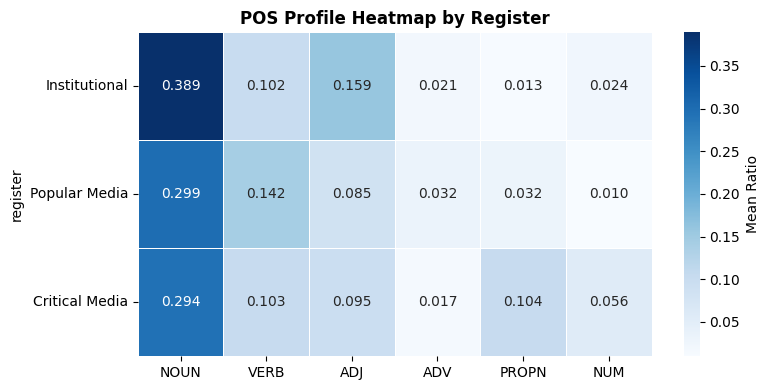

Figure saved: step2_pos_heatmap.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pos_plot, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Mean Ratio"})
ax.set_title("POS Profile Heatmap by Register", fontsize=12, fontweight="bold")
ax.set_yticklabels(register_labels, rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("step2_pos_heatmap.png", dpi=150)
plt.show()
print("Figure saved: step2_pos_heatmap.png")

## 7. Qualitative Analysis — Top POS Tokens per Register

For each register, identify the **most frequent nouns and verbs** to understand which specific lexical items drive the POS profile.

In [9]:
def top_pos_tokens(register_name, pos_tag, top_n=15):
    """
    Returns the top_n most frequent lemmas for a given POS tag in a given register.
    """
    texts = df_pos[df_pos["register"] == register_name]["text"].tolist()
    token_list = []
    for text in texts:
        doc = nlp(text)
        for token in doc:
            if token.pos_ == pos_tag and not token.is_stop and not token.is_punct:
                token_list.append(token.lemma_.lower())
    return Counter(token_list).most_common(top_n)

print("=== Top 10 NOUNs per register ===")
for reg in register_order:
    top = top_pos_tokens(reg, "NOUN", top_n=10)
    print(f"\n{reg.upper()}:")
    print([f"{w}({c})" for w, c in top])

print("\n=== Top 10 VERBs per register ===")
for reg in register_order:
    top = top_pos_tokens(reg, "VERB", top_n=10)
    print(f"\n{reg.upper()}:")
    print([f"{w}({c})" for w, c in top])

=== Top 10 NOUNs per register ===

INSTITUTIONAL:
['employment(34)', 'worker(32)', 'labor(20)', 'rate(16)', 'percent(14)', 'formality(11)', 'informality(10)', 'survey(9)', 'sector(8)', 'level(8)']

POPULAR_MEDIA:
['day(13)', 'street(10)', 'contract(10)', 'week(10)', 'income(8)', 'school(8)', 'man(8)', 'worker(7)', 'pension(7)', 'saving(7)']

CRITICAL_MEDIA:
['labor(36)', 'worker(33)', 'percent(22)', 'employment(16)', 'firm(13)', 'program(12)', 'contribution(12)', 'informality(11)', 'sector(7)', 'rate(7)']

=== Top 10 VERBs per register ===

INSTITUTIONAL:
['indicate(11)', 'exhibit(8)', 'remain(7)', 'employ(5)', 'fall(4)', 'reveal(4)', 'reflect(4)', 'decline(4)', 'estimate(4)', 'suggest(3)']

POPULAR_MEDIA:
['sell(14)', 'earn(14)', 'work(13)', 'pay(13)', 'mean(9)', 'say(7)', 'come(6)', 'go(5)', 'set(4)', 'know(3)']

CRITICAL_MEDIA:
['document(9)', 'find(5)', 'require(5)', 'classify(4)', 'issue(4)', 'extend(4)', 'exceed(4)', 'operate(4)', 'exclude(4)', 'produce(4)']


## 8. Save Output

In [10]:
output_path = "corpus_pos.csv"
df_pos.to_csv(output_path, index=False)
print(f"Output saved: {output_path}")
print(f"Final shape: {df_pos.shape}")
print(f"Columns: {df_pos.columns.tolist()}")

Output saved: corpus_pos.csv
Final shape: (180, 20)
Columns: ['text', 'text_clean', 'label', 'register', 'prompt_id', 'token_count_original', 'token_count_clean', 'total_tokens', 'count_noun', 'ratio_noun', 'count_verb', 'ratio_verb', 'count_adj', 'ratio_adj', 'count_adv', 'ratio_adv', 'count_propn', 'ratio_propn', 'count_num', 'ratio_num']


## 9. Summary of Findings

*(Fill in after running the notebook — use the cell below as a template)*

In [11]:
print("=== STEP 2 SUMMARY ===")
print("\nMean POS ratios by register:")
print(pos_by_register.to_string())

print("\n--- Interpretation template ---")
noun_vals = pos_by_register["NOUN"]
verb_vals = pos_by_register["VERB"]

most_noun = noun_vals.idxmax()
most_verb = verb_vals.idxmax()

print(f"Register with highest NOUN ratio: {most_noun} ({noun_vals.max():.3f})")
print(f"Register with highest VERB ratio: {most_verb} ({verb_vals.max():.3f})")
print("\nNext step: Step 3 — Domain Dictionary Filtering")
print("Input file for Step 3: corpus_pos.csv")

=== STEP 2 SUMMARY ===

Mean POS ratios by register:
                  NOUN    VERB     ADJ     ADV   PROPN     NUM
register                                                      
critical_media  0.2936  0.1034  0.0952  0.0172  0.1039  0.0560
institutional   0.3894  0.1015  0.1590  0.0213  0.0125  0.0237
popular_media   0.2992  0.1424  0.0847  0.0321  0.0316  0.0098

--- Interpretation template ---
Register with highest NOUN ratio: institutional (0.389)
Register with highest VERB ratio: popular_media (0.142)

Next step: Step 3 — Domain Dictionary Filtering
Input file for Step 3: corpus_pos.csv
